In [1]:
# Task 1 — Data Exploration with Pandas 

import pandas as pd
df = pd.read_csv("students.csv")

# 1. Print the first 5 rows using 
print(df.head())

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  


In [2]:

# 2. Print the shape (rows × columns) and the data type of each column using .dtypes.
print("\nShape:", df.shape)
print("\nData Types:\n", df.dtypes)


Shape: (15, 9)

Data Types:
 name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


In [3]:
# 3. Print summary statistics (mean, min, max, std) for all numeric columns using .describe().
print("\nSummary Statistics:\n", df.describe())


Summary Statistics:
             math    science    english    history         pe  attendance_pct  \
count  15.000000  15.000000  15.000000  15.000000  15.000000       15.000000   
mean   65.000000  66.733333  66.200000  63.400000  74.800000       75.800000   
std    20.060622  18.967893  17.773174  16.936014  16.657045       14.722189   
min    30.000000  35.000000  40.000000  28.000000  45.000000       50.000000   
25%    51.500000  53.500000  49.000000  53.500000  61.000000       63.500000   
50%    65.000000  65.000000  70.000000  62.000000  75.000000       78.000000   
75%    80.000000  77.000000  81.000000  73.500000  89.000000       86.500000   
max    95.000000  98.000000  91.000000  92.000000  97.000000       98.000000   

       study_hours_per_day     passed  
count            15.000000  15.000000  
mean              2.893333   0.600000  
std               1.658944   0.507093  
min               0.500000   0.000000  
25%               1.650000   0.000000  
50%              

In [4]:
# 4. Print the count of students who passed and who failed. (Hint: use df['passed'].value_counts())
print("\nPass vs Fail Summary:")

counts = df["passed"].value_counts()

print(f"Passed: {counts.get(1, 0)}")
print(f"Failed: {counts.get(0, 0)}")



Pass vs Fail Summary:
Passed: 9
Failed: 6


In [6]:
# 5. Compute and print the average score per subject 
subject_cols = ['math', 'science', 'english', 'history', 'pe']

# Passing students
pass_avg = df[df["passed"] == 1][subject_cols].mean()
print("\nAverage Scores (Pass):\n", pass_avg)

# Failing students
fail_avg = df[df["passed"] == 0][subject_cols].mean()
print("\nAverage Scores (Fail):\n", fail_avg)

# 6. Find and print the student with the highest overall average across all 5 subjects. 
# (Hint: compute a temporary average column using .mean(axis=1) on the subject columns.)

df["avg_score"] = df[subject_cols].mean(axis=1)

# Find max
top_student = df.loc[df["avg_score"].idxmax()]

print("\nTop Student: ", top_student["name"], "-", round(top_student["avg_score"], 2))


Average Scores (Pass):
 math       78.222222
science    78.555556
english    79.111111
history    73.444444
pe         86.000000
dtype: float64

Average Scores (Fail):
 math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64

Top Student:  Diana - 94.0


In [7]:
# Task 2 — Data Visualization with Matplotlib

import pandas as pd
import matplotlib.pyplot as plt

# Before starting, add a new column to your DataFrame:
df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

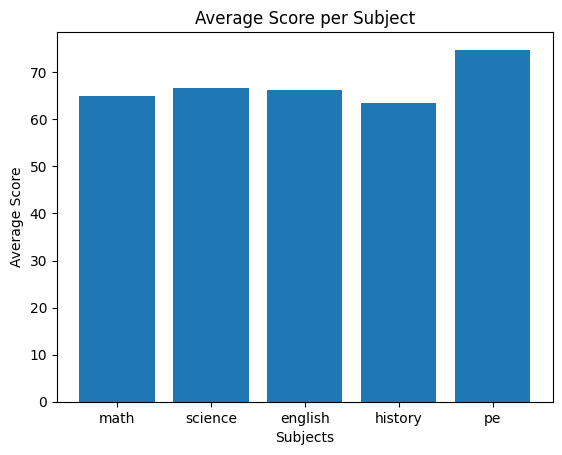

In [8]:
# 1. Bar Chart — Average score per subject across all students (one bar per subject, x-axis = subject name, y-axis = average score).
avg_scores = df[subject_cols].mean()

plt.figure()
plt.bar(avg_scores.index, avg_scores.values)

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")

plt.savefig("plot1_bar.png")
plt.show()

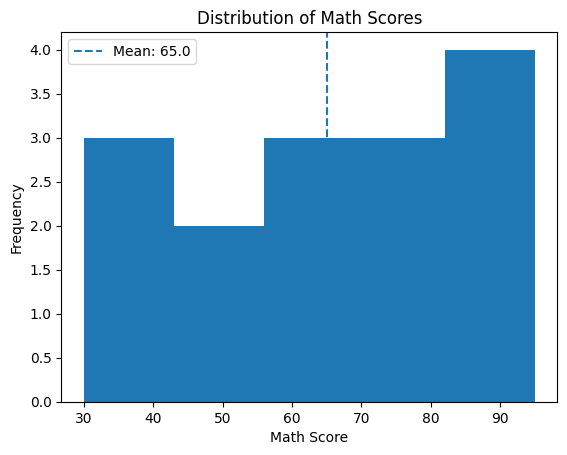

In [9]:
# 2. Histogram — Distribution of math scores. Use 5 bins. Add a vertical dashed line at the mean math score and label it

plt.figure()

plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()

plt.axvline(mean_math, linestyle='dashed', label=f"Mean: {round(mean_math,2)}")

plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")

plt.legend()

plt.savefig("plot2_hist.png")
plt.show()

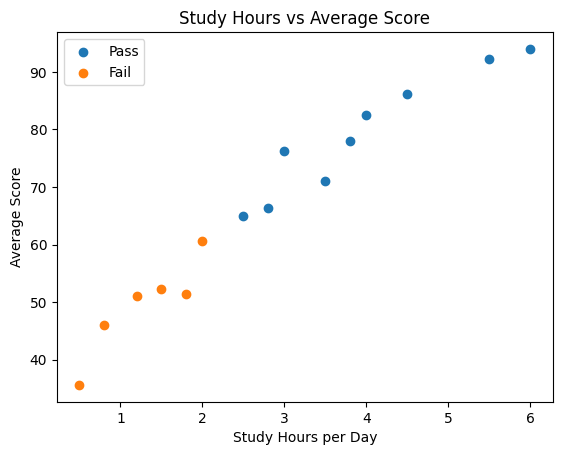

In [10]:
# 3. Scatter Plot — study_hours_per_day (x-axis) vs avg_score (y-axis). 
# Colour each point differently based on passed: one colour for Pass, another for Fail. Include a legend.

plt.figure()

# Pass students
pass_df = df[df['passed'] == 1]
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")

# Fail students
fail_df = df[df['passed'] == 0]
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")

plt.legend()

plt.savefig("plot3_scatter.png")
plt.show()

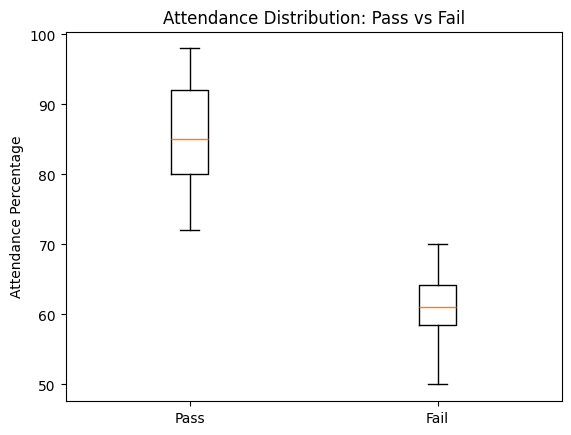

In [12]:
# 4. Box Plot — Show the distribution of attendance_pct for passing students vs failing students side by side
plt.figure()

pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.boxplot([pass_attendance, fail_attendance], tick_labels=['Pass', 'Fail'])

plt.title("Attendance Distribution: Pass vs Fail")
plt.ylabel("Attendance Percentage")

plt.savefig("plot4_box.png")
plt.show()

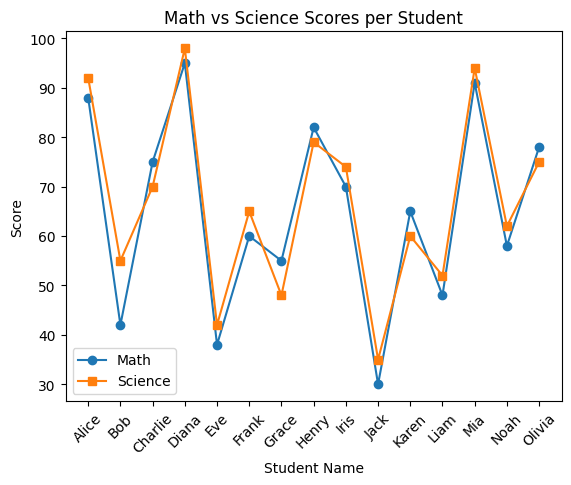

In [13]:
# 5. Line Plot — Plot the math score and science score for every student. X-axis = student name, Y-axis = score. 
# Use different line styles or markers for each subject.

plt.figure()

plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='s', label="Science")

plt.title("Math vs Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")

plt.xticks(rotation=45)

plt.legend()

plt.savefig("plot5_line.png")
plt.show()

In [ ]:
# Task 3 — Data Visualization with Seaborn

import seaborn as sns

df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

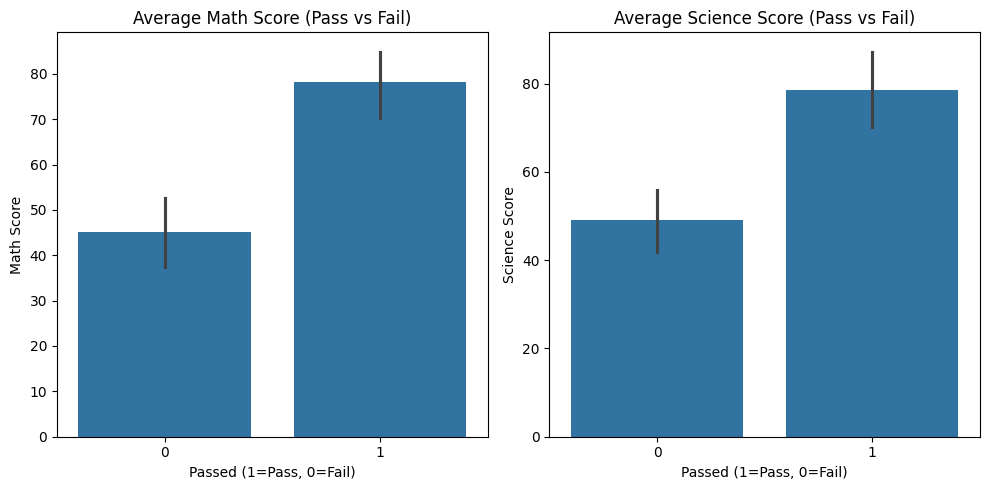

In [15]:
# 1. Create a Seaborn bar plot
plt.figure(figsize=(10, 5))

# Subplot 1 → Math
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math')
plt.title("Average Math Score (Pass vs Fail)")
plt.xlabel("Passed (1=Pass, 0=Fail)")
plt.ylabel("Math Score")

# Subplot 2 → Science
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science')
plt.title("Average Science Score (Pass vs Fail)")
plt.xlabel("Passed (1=Pass, 0=Fail)")
plt.ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

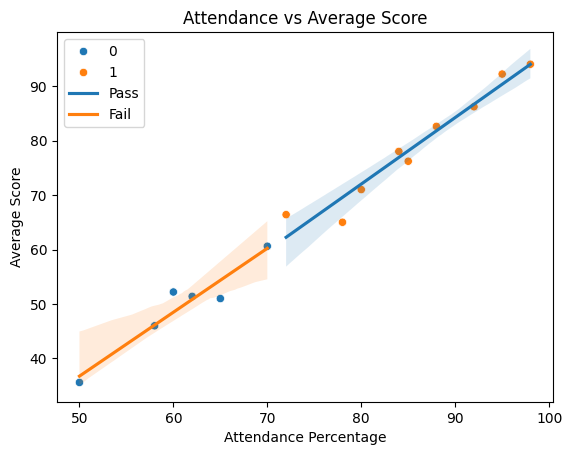

In [16]:
# 3. Create a Seaborn scatter plot of attendance_pct (x-axis) vs avg_score (y-axis), coloured by passed
plt.figure()

# Scatter plot (colored by passed)
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression line for Pass
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Pass'
)

# Regression line for Fail
sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    scatter=False,
    label='Fail'
)

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")

plt.legend()

plt.savefig("plot7_seaborn_scatter.png")
plt.show()

In [ ]:
# 4. Write 2–3 sentences as a comment in your code comparing your experience of using Seaborn vs Matplotlib for these plots 


# Seaborn vs Matplotlib:
# Seaborn makes plotting much easier and cleaner, especially for statistical visualizations like barplots and regression lines.
# It automatically handles grouping, colors, and aesthetics, which required more manual work in Matplotlib.
# However, Matplotlib provides more granular control, while Seaborn is faster for high-level analysis.

In [18]:
# Task 4 — Machine Learning with scikit-learn 

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1 — Prepare Data:

df = pd.read_csv("students.csv")

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1. Separate features and target. Keep the original df intact (do not drop the name column from df — only exclude it from X.
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]

# Target
y = df['passed']

# 2. Split into train (80%) and test (20%) sets:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3. Scale features using StandardScaler — fit on training data only, then transform both sets
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)  # fit only on train
X_test_scaled = scaler.transform(X_test)

In [26]:
# Step 2 — Train a Model:

# 1. Train a LogisticRegression model on the scaled training data.
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)

# 2. Print the model's training accuracy.
print("Training Accuracy:", round(train_acc, 2))

# Step 3 — Evaluate the Model:
# 1. Predict on the test set.
y_pred = model.predict(X_test_scaled)

# 2. Print the test accuracy.
test_acc = model.score(X_test_scaled, y_test)
print("Test Accuracy:", round(test_acc, 2))

print("\nTest Predictions:\n")
# 3. For each student in the test set, print their name alongside the actual label and predicted label, and whether the prediction was ✅ correct or ❌ wrong.
test_names = df.loc[X_test.index, 'name']

for name, actual, pred in zip(test_names, y_test, y_pred):
    status = "✅ Correct" if actual == pred else "❌ Wrong"
    
    actual_label = "Pass" if actual == 1 else "Fail"
    pred_label = "Pass" if pred == 1 else "Fail"
    
    print(f"{name}: Actual = {actual_label}, Predicted = {pred_label} → {status}")

Training Accuracy: 1.0
Test Accuracy: 1.0

Test Predictions:

Jack: Actual = Fail, Predicted = Fail → ✅ Correct
Liam: Actual = Fail, Predicted = Fail → ✅ Correct
Alice: Actual = Pass, Predicted = Pass → ✅ Correct



Feature Importance:
english: 0.813
attendance_pct: 0.522
study_hours_per_day: 0.484
pe: 0.475
math: 0.438
science: 0.323
history: 0.263


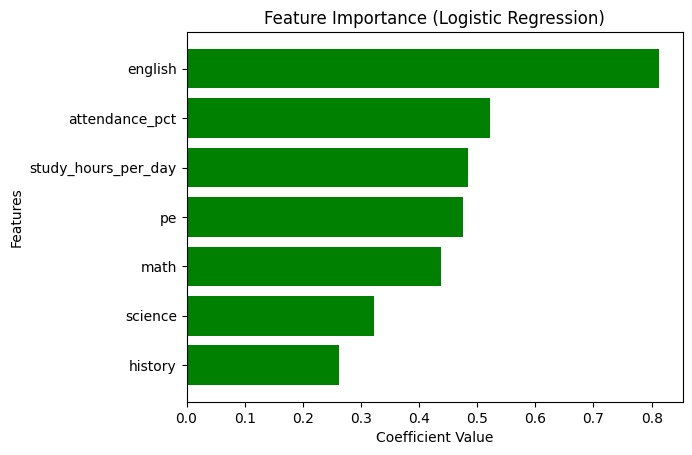

In [ ]:
# Step 4 — Feature Importance:
import numpy as np
import matplotlib.pyplot as plt

# 1.Extract the model coefficients: model.coef_[0] — these are one value per feature.
coefficients = model.coef_[0]

feature_importance = list(zip(feature_cols, coefficients))

# 2. Pair each coefficient with its feature name and print them, sorted by absolute value (largest first).
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance:")
for feature, coef in feature_importance:
    print(f"{feature}: {round(coef, 3)}")


features = [f[0] for f in feature_importance]
values = [f[1] for f in feature_importance]

# 3. Create a horizontal bar chart using Matplotlib showing all feature coefficients. (Color logic)
colors = ['green' if v > 0 else 'red' for v in values]

plt.figure()

plt.barh(features, values, color=colors)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.gca().invert_yaxis()  # highest at top

plt.savefig("plot8_feature_importance.png")
plt.show()

In [31]:
# Step 5 — Predict for a New Student

# Define a new student with values of your choice:
new_student = pd.DataFrame(
    [[75, 70, 68, 65, 80, 82, 3.2]],
    columns=feature_cols
)

# Scale
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

label = "Pass" if prediction == 1 else "Fail"

print("\nNew Student Prediction:")
print("Prediction:", label)
print("Probability (Fail, Pass):", probability)


New Student Prediction:
Prediction: Pass
Probability (Fail, Pass): [0.09203526 0.90796474]
